# HR Attrition Analysis
- **Goal**: Identify which employee factors are most associated with attrition.
- **Dataset**: IBM HR Attrition Analytics dataset (Kaggle), 1480 employee records, 35 columns.

**Note on data cleaning:** This dataset is pre-cleaned and synthetic (IBM sample data) — it contains no missing values and no messy fields. No cleaning or feature engineering was required beyond selecting relevant columns. 

## 1. Setup and Data Loading

In [23]:
# import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("hr_employee_attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview

In [38]:
print(f'Missing values per column: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

df['Attrition'].value_counts(normalize=True) * 100

Missing values per column: 0
Duplicate Rows: 0


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

**Baseline**: 16.1% employees in this dataset left the company (237 of 1470). Every finding below is measures against this baseline.

The idea is:

- If a group's attrition rate is close to 16.1%, that factor probably isn't having much effect.
- If it's much higher than 16.1%, it may be increasing attrition.
- If it's much lower than 16.1%, it may be reducing attrition.

## 2. Testing Candidate Attrition Drivers

In [46]:
def attrition_rate_by(col, bins = None, labels = None):
    data = df.copy()
    if bins is not None:
        data[col] = pd.cut(data[col], bins=bins, labels=labels)
    rate = pd.crosstab(
        data[col],
        data['Attrition'],
        normalize = 'index'
    )['Yes'] * 100
    return rate.sort_values(ascending = False)

In [57]:
overtime_rate = attrition_rate_by('OverTime')
overtime_rate

OverTime
Yes    30.528846
No     10.436433
Name: Yes, dtype: float64

In [59]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[17,25,35,45,60], labels=['18-25','26-35','36-45','46-60'])
age_rate = attrition_rate_by('AgeGroup')
age_rate

AgeGroup
18-25    35.772358
26-35    19.141914
46-60    12.454212
36-45     9.188034
Name: Yes, dtype: float64

In [63]:
marital_rate = attrition_rate_by('MaritalStatus')
marital_rate

MaritalStatus
Single      25.531915
Married     12.481426
Divorced    10.091743
Name: Yes, dtype: float64

In [62]:
jobrole_rate = attrition_rate_by('JobRole')
jobrole_rate

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Yes, dtype: float64

In [65]:
travel_rate = attrition_rate_by('BusinessTravel')
travel_rate

BusinessTravel
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Non-Travel            8.000000
Name: Yes, dtype: float64

In [54]:
income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median']).round(0)
income_by_attrition 

,mean,median
Attrition,,
No,6833.0,5204.0
Yes,4787.0,3202.0


In [55]:
print(attrition_rate_by('Education'))

Education
1    18.235294
3    17.307692
2    15.602837
4    14.572864
5    10.416667
Name: Yes, dtype: float64


**Correction on the previous analysis**: it originally project claimed higher education was associated with higher attrition. The numbers show opposite - attrition decreases as education level rises (18.2% at level 1 down to 10.4% at level 5). The earlier claim was not supported by the data and has been dropped.

## 3. Visializations of the strongest drivers

Overtime, age and job role show the largest spred from baseline

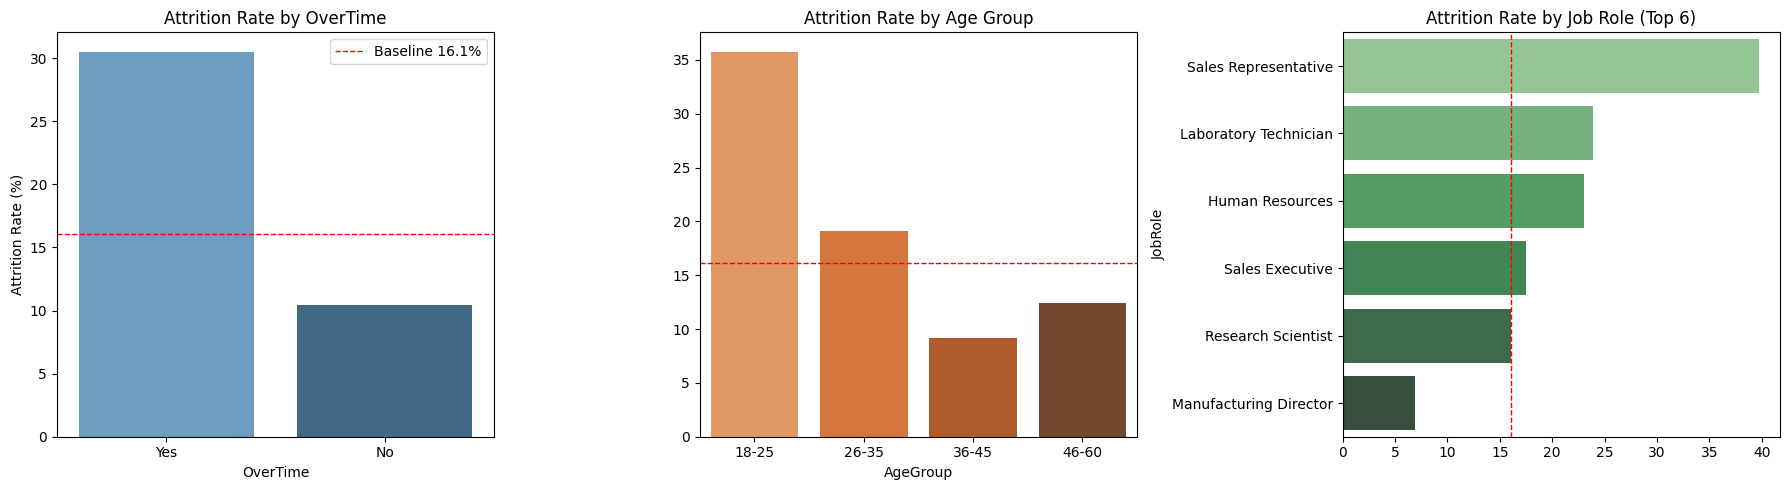

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(
    x=overtime_rate.index,
    y=overtime_rate.values,
    hue=overtime_rate.index,
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Attrition Rate by OverTime')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].axhline(16.1, color='red', linestyle='--', linewidth=1, label='Baseline 16.1%')
axes[0].legend()

sns.barplot(
    x=age_rate.index,
    y=age_rate.values,
    hue=age_rate.index,
    order=['18-25', '26-35', '36-45', '46-60'],
    palette='Oranges_d',
    legend=False,
    ax=axes[1]
    )
axes[1].set_title('Attrition Rate by Age Group')
axes[1].axhline(16.1, color='red', linestyle='--', linewidth=1)

top_roles = jobrole_rate.head(6)
sns.barplot(
    x=top_roles.values,
    y=top_roles.index,
    hue=top_roles.index,
    palette='Greens_d',
    legend=False,
    ax=axes[2]
    )
axes[2].set_title('Attrition Rate by Job Role (Top 6)')
axes[2].axvline(16.1, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


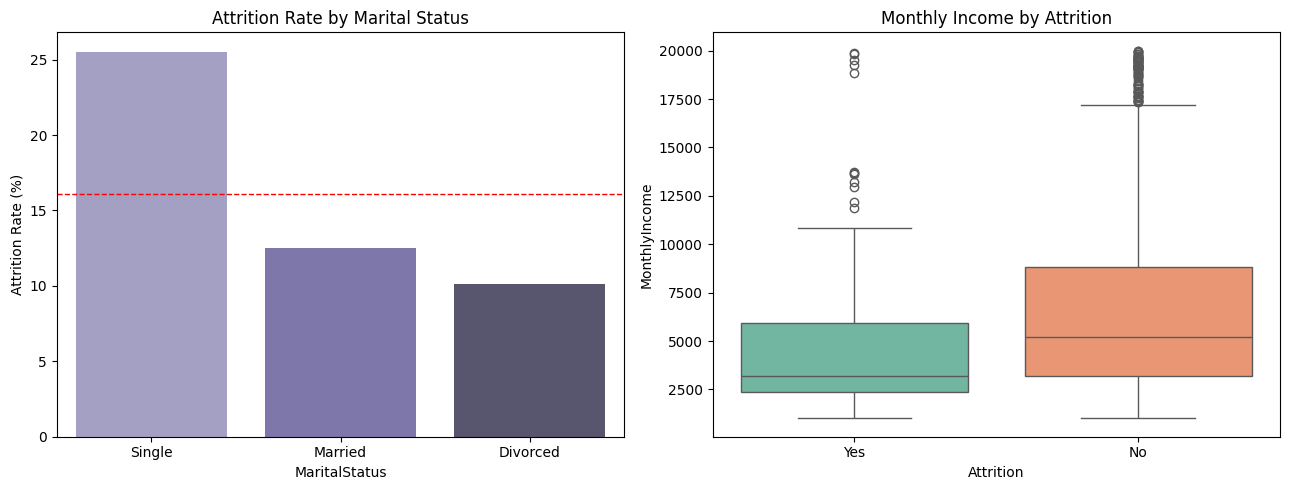

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(x=marital_rate.index, y=marital_rate.values, ax=axes[0], palette='Purples_d', hue=marital_rate.index)
axes[0].set_title('Attrition Rate by Marital Status')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].axhline(16.1, color='red', linestyle='--', linewidth=1)

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1], palette='Set2', hue='Attrition')
axes[1].set_title('Monthly Income by Attrition')

plt.tight_layout()
plt.show()

## 4. Findings & Suggested Next Steps

*The findings below are associations found in this dataset. The "worth testing" notes are hypotheses for further investigation, not proven interventions - this dataset can't establish causation.*

**1. Overtime is the single strongest driver.** Employees working overtime leave at **30.5%**, nearly 3x the rate of those who don't (**10.4%**). *Worth testing: whether reducing overtime load in high-turnover teams (Sales, Lab Technicians) affects retention - the dataset can't confirm overtime causes attrition rather than reflecting an already-stressful role.*

**2. Attrition is concentrated in young employees.** The 18-25 age group leaves at **35.8%**, more than double the overall baseline, dropping to **9.2%** for 36-45. *Worth testing: early-career retention programs (mentorship, clear promotion timelines) as a pilot — this dataset can't confirm which specific intervention would work.*

**3. Sales Representatives are the highest-risk role.** **39.8%** attrition, far above every other role (next highest: Lab Technician at 23.9%, Research Director at just 2.5%). *Worth testing: Sales Rep-specific factors (compensation structure, quota pressure) as a further investigation - flagged here as a segment, not a diagnosed cause.*

**4. Single employees leave at double the rate of married employees** (25.5% vs 12.5%), and frequent travelers leave at **24.9%** vs 8.0% for non-travelers. *Worth testing: whether these factors genuinely compound (e.g. are single employees also disproportionately young?) - the overlap hasn't been tested, so treat this as a risk profile to monitor rather than a confirmed segment.*

**5. Leavers earn less on average** (₹4,787 vs ₹6,833 mean monthly income), consistent with overtime/role findings rather than a standalone driver.

**Dropped from v1 (not supported by data):** the claim that higher education correlates with *higher* attrition - verified data shows the reverse. Years-since-last-promotion showed almost no difference between leavers and stayers (1.95 vs 2.23) and is not included as a finding.